In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np

In [2]:
plt.style.use('style.mplstyle')
sns.set_context('talk', font_scale=1.0)
fig_folder = os.path.abspath("figures/")

# 0. Load Mutagenicity Dataset

In [3]:
# only select a single dataset
dataset = 'mutagenicity'
# consider dummy atoms
remove_dummies = False

rename_datasets = {'mutagenicity': 'mutagenicity', # need to use different dataset
                   }

files = ['./rf_classification_mutagenicity/df_explanation.pkl']
df_mut = pd.concat((pd.read_pickle(sol_file) for sol_file in files))

df_mut = df_mut.loc[df_mut.dataset == dataset]
df_mut['dataset'] = df_mut['dataset'].replace(rename_datasets)

# 1. Get List of Fragments and their Shapley Values Across all Splits

In [4]:
from rdkit.Chem import MolFromSmiles, MolToSmiles, FragmentOnBRICSBonds, GetMolFrags
from rdkit.Chem import RWMol, SanitizeMol
from rdkit.Chem import ReplaceSubstructs, RemoveAllHs

def remove_isotope_information_for_dummy_atoms(m):
    '''
        Removes the isotope information from dummy atoms (denoted as *). Does nothing if molecule does not have a dummy atom

        input:
            m : rdkit.Mol, Molecule

        output:
            rdkit.Mol, Molecule without isotope information at dummy atoms
    '''
    for at in m.GetAtoms():
        if at.GetSymbol() == '*':
            at.SetIsotope(0)
    return m

def remove_dummy_atoms(m):
    '''
        Removed dummy atoms (denoted as *) from molecule. Works by replacing dummy atom(s) with hydrogen(s)

        input:
            m : rdkit.Mol, Molecule
        
        output:
            rdkit.Mol, sanitized Molecule without dummy atom(s)
    '''
    dummy = MolFromSmiles('*')
    m_cleaned = ReplaceSubstructs(m, dummy, MolFromSmiles('[H]'), replaceAll=True)[0]
    return RemoveAllHs(m_cleaned, sanitize=True)

def get_BRICS_fragments_as_SMILES(smiles, remove_dummies=False):
    '''
        Fragments a SMILES using BRICS and returns the fragments as a list of SMILES. First, turns the input SMILES into rdkit.Mol.
        Followed by fragmenting using BRICS and removal of isotope information on the cleavage sites.

        input:
            smiles: str, SMILES string of molecule to fragment
            remove_dummies: bool, default False, flag to remove dummy atoms from fragments

        output:
            List[str] list of SMILES without isotope information and depending on remove_dummies with or without dummy atoms
    '''
    mol = MolFromSmiles(smiles)
    frag_ = FragmentOnBRICSBonds(mol)
    frags = GetMolFrags(frag_,
                        asMols=True)
    frags_cleaned = [remove_isotope_information_for_dummy_atoms(m) for m in frags]
    if remove_dummies:
        frags_cleaned = [remove_dummy_atoms(m) for m in frags_cleaned]
        
    return [MolToSmiles(m) for m in frags_cleaned]

In [5]:
df_mut['fragments'] = df_mut.smiles.apply(lambda x: get_BRICS_fragments_as_SMILES(x, remove_dummies=remove_dummies))

In [6]:
# get the values of the Explainer as a list (currently only available as dict)
df_mut['fragExplainer_shapley_values'] = df_mut.fragExplainer_result.apply(lambda x: list(x.values()))
# create a dataframe of all fragments (contains duplicates) and the corresponding Shapley Value
df_fragments = df_mut[['fragments', 'fragExplainer_shapley_values']].explode(['fragments', 'fragExplainer_shapley_values'], ignore_index=True)

In [7]:
df_fragments = df_fragments.groupby('fragments').agg([len, 'mean', 'std', list]) # will throw warning veacuse of error when calculating std for a single measurement
df_fragments = df_fragments.reset_index() # reset so that 'fragments' is a column again and no longer the index
df_fragments.columns = [col[0] if col[1]=='' else col[1] for col in df_fragments.columns.values] # rename, choose 'fragments' for first column, for the other simply len, mean, std
df_fragments

,fragments,len,mean,std,list
0,*=C(Br)C(=O)O,1,0.591398,NaN,[0.5913979735233463]
1,*=C(Br)C=O,2,2.222427,0.048048,"[2.2564019236348143, 2.188451378489835]"
2,*=C(Br)CO,2,1.145702,0.000000,"[1.1457017105344467, 1.1457017105344467]"
3,*=C(C#N)C#N,5,0.100632,0.106617,"[0.13035033377444694, 0.13035033377444694, 0.2..."
4,*=C(C#N)CCC(=O)O,1,0.780244,NaN,[0.7802440305488524]
...,...,...,...,...,...
5664,c1cnc2cnncc2c1,1,1.91012,NaN,[1.91011992403508]
5665,c1cnccn1,1,0.784113,NaN,[0.7841126052922147]
5666,c1cscn1,1,0.992124,NaN,[0.9921235076421391]
5667,c1scc2c1-c1cscc1C1NC21,1,2.631376,NaN,[2.6313756393388883]


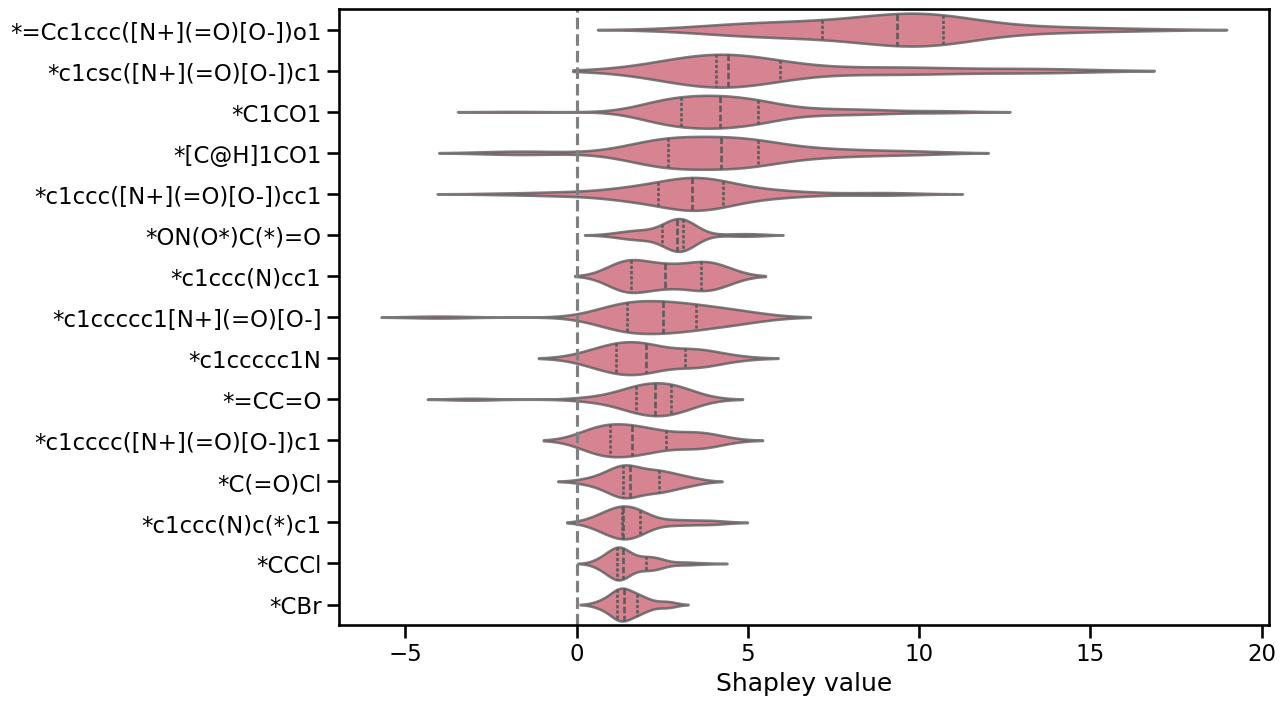

In [11]:
# now get the smiles to consider
min_n = 20
top_k = 15

# get list of SMILES of the fragments that appear at least min_n times and are most contriuting towards mutagenicity
df_plot = df_fragments.sort_values(by='mean', ascending=False).query('len >= @min_n').head(top_k)

fig, axs = plt.subplots(1, 
                        1,
                        figsize=(12, 8))
axs.axvline(x=0, color='gray', ls='--') # line to indicate change from positive to negative influence

sns.violinplot(df_plot.explode('list'), # need to explode to get the list untangled
               x='list',
               y='fragments',
               inner='quart',
               density_norm='width',
               ax=axs
               )

# color the violins individually based on whether their average contribution is above zero or not
col_negative = sns.color_palette()[4]
col_positive = sns.color_palette()[0]
color_list = list(col_negative if mv < 0 else col_positive for mv in df_plot['mean'])
for violin, color in zip(axs.collections, color_list):
    violin.set_facecolor(color)
    violin.set_alpha(0.8)

# fix labels
axs.set_ylabel('')
axs.set_xlabel('Shapley value')

fig.savefig(os.path.join(fig_folder, f'3_{dataset}_violin_min_{min_n}.pdf'), 
            bbox_inches='tight',
            )